In [2]:
import pandas as pd
import matplotlib.pyplot as plt # visualizing data
import seaborn as sns

In [3]:
df = pd.read_csv("dataset_olympics.csv")

In [13]:
df.head()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN


In [3]:
df.describe()

,ID,Age,Height,Weight,Year
count,70000.000000,67268.000000,53746.000000,52899.000000,70000.000000
mean,18081.846986,25.644645,175.505303,70.900216,1977.766457
std,10235.613253,6.485239,10.384203,14.217489,30.103306
min,1.000000,11.000000,127.000000,25.000000,1896.000000
25%,9325.750000,21.000000,168.000000,61.000000,1960.000000
50%,18032.000000,25.000000,175.000000,70.000000,1984.000000
75%,26978.000000,28.000000,183.000000,79.000000,2002.000000
max,35658.000000,88.000000,223.000000,214.000000,2016.000000


In [22]:
df.isna().sum()

ID            0
Name          0
Sex           0
Age        2732
Height    16254
Weight    17101
Team          0
NOC           0
Games         0
Year          0
Season        0
City          0
Sport         0
Event         0
Medal     60310
dtype: int64

In [23]:
df.duplicated().sum()

383

In [24]:
df.drop_duplicates(inplace=True)

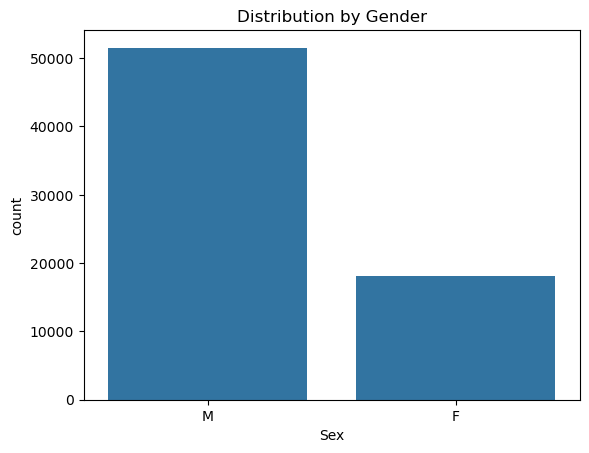

In [8]:
sns.countplot(data=df, x="Sex")
plt.title("Distribution by Gender")
plt.show()

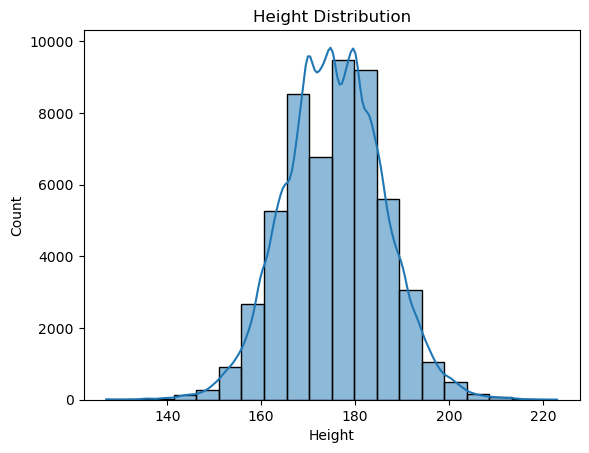

In [9]:
sns.histplot(data = df, x="Height", bins=20, kde=True)
plt.title("Height Distribution")
plt.show()

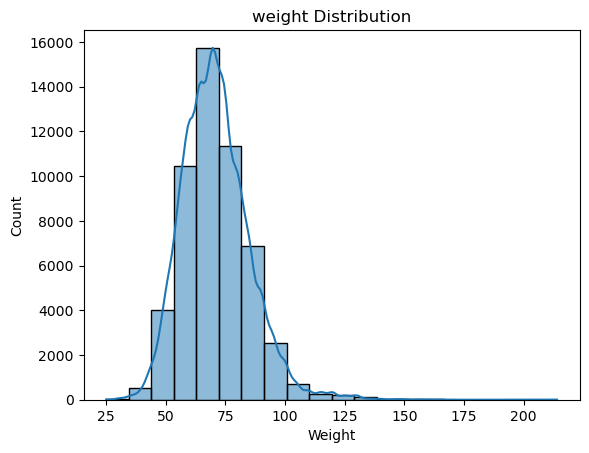

In [11]:
sns.histplot(data = df, x="Weight",bins=20, kde=True)
plt.title("weight Distribution")
plt.show()

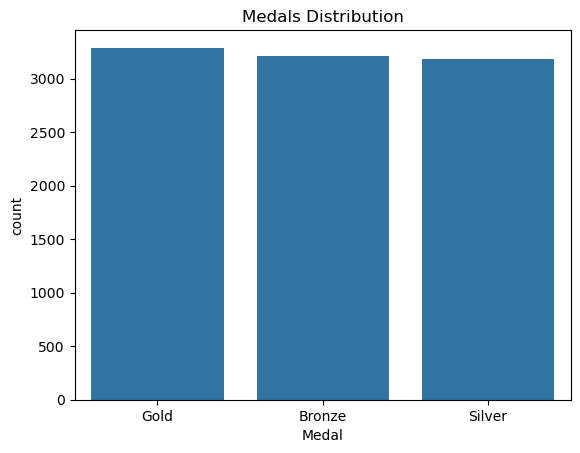

In [14]:
sns.countplot(data = df, x= "Medal")
plt.title("Medals Distribution")
plt.show()

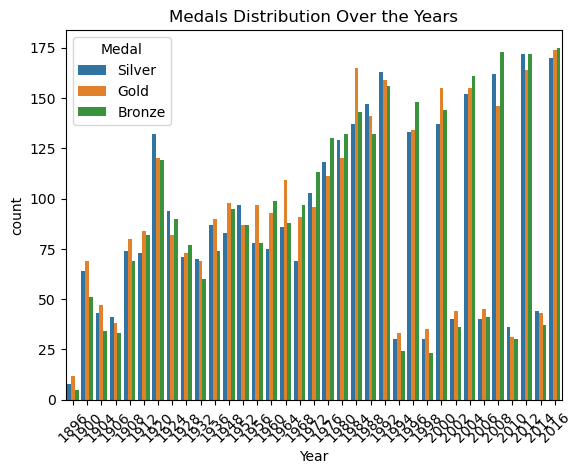

In [15]:
sns.countplot(data = df, x= "Year", hue="Medal")
plt.title("Medals Distribution Over the Years")
plt.xticks(rotation=45)
plt.show()

In [16]:
year_avg_age= df.groupby("Year")["Age"].mean()
print(year_avg_age)

Year
1896    23.029412
1900    29.119883
1904    27.063241
1906    26.989474
1908    27.000000
1912    27.965552
1920    29.241135
1924    28.252267
1928    27.973564
1932    29.606987
1936    27.245665
1948    28.363170
1952    26.273684
1956    26.316156
1960    25.136156
1964    24.852107
1968    24.316722
1972    24.126448
1976    23.656820
1980    23.312364
1984    24.060328
1988    24.257374
1992    24.637827
1994    24.487516
1996    25.338210
1998    25.143860
2000    25.435177
2002    26.029095
2004    25.780111
2006    26.091716
2008    25.685148
2010    26.150776
2012    25.993485
2014    26.082814
2016    26.259592
Name: Age, dtype: float64


In [20]:
# Group by sport & height of the participatend to find the median value and max value

sport_media_height = df.groupby("Sport")["Height"].median()
print(sport_media_height.max())
print(sport_media_height.min())

190.0
164.0


In [24]:
# To find which sport name have the max/min height from sport_media_height...
# sport_media_height[sport_media_height == 190.0]
sport_media_height[sport_media_height == 164.0]

Sport
Gymnastics    164.0
Name: Height, dtype: float64

In [27]:
# Count the male and female participatend  from every county we have
country_gender_count = df.groupby(["NOC", "Sex"])["ID"].count()
print(country_gender_count)

NOC  Sex
AFG  M       38
AHO  F        6
     M       27
ALB  F        4
     M        7
           ... 
YUG  M      455
ZAM  F        3
     M       40
ZIM  F       41
     M       47
Name: ID, Length: 432, dtype: int64


In [4]:
# group by medal and country whose have glod by count...
country_gold_medals = df[df["Medal"] == "Gold"].groupby("NOC")["Medal"].count()
print(country_gold_medals)

NOC
ALG      1
ANZ      7
ARG     25
ARM      1
AUS     98
      ... 
URU     13
USA    747
UZB      4
YUG     31
ZIM      7
Name: Medal, Length: 84, dtype: int64


In [6]:
# group by sport and sex with weight to find the mwan value of the database.
sport_gender_avg_weight = df.groupby(["Sport","Sex"])["Weight"].mean()
print(sport_gender_avg_weight["Archery"])    # to find the specific sex in the sport.

Sex
F    61.023256
M    78.797468
Name: Weight, dtype: float64


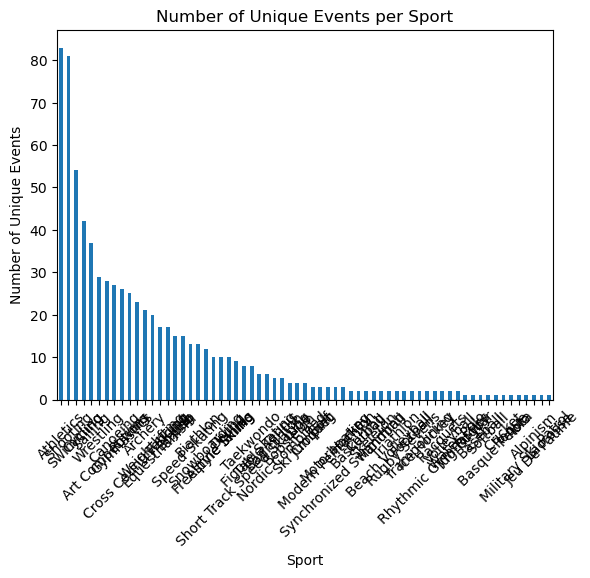

In [10]:
# group by all the event happend in the sports(unique event)...

sport_event_count = df.groupby("Sport")["Event"].nunique().sort_values(ascending=False)
sport_event_count.plot(kind="bar")
plt.title("Number of Unique Events per Sport")
plt.xlabel("Sport")
plt.ylabel("Number of Unique Events")
plt.xticks(rotation = 45)
plt.show()

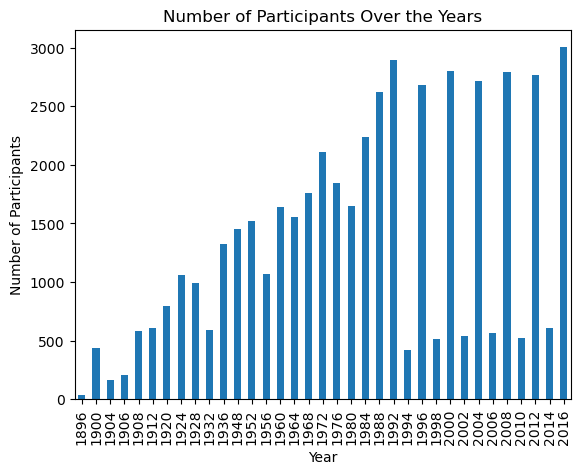

In [12]:
# how many unique pariciapnt does pariciapanted by year...
year_pariciapant_count = df.groupby("Year")["ID"].nunique()
year_pariciapant_count.plot(kind="bar")
plt.title("Number of Participants Over the Years")
plt.xlabel("Year")
plt.ylabel("Number of Participants")
plt.show()

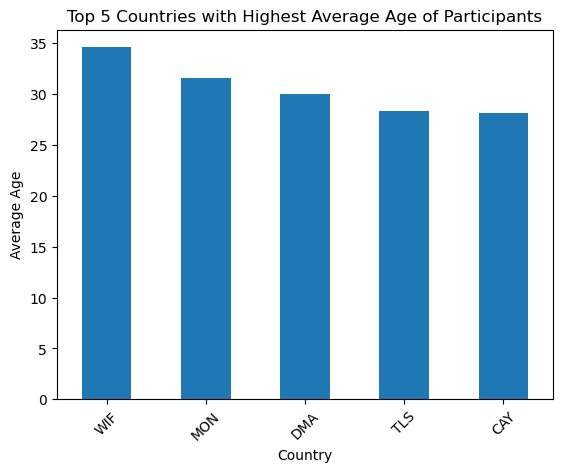

In [13]:
# find the avgerage age of all the country...
country_avg_age = df.groupby("NOC")["Age"].mean().sort_values(ascending=False)
country_avg_age.head(5).plot(kind="bar")
plt.title("Top 5 Countries with Highest Average Age of Participants")
plt.xlabel("Country")
plt.ylabel("Average Age")
plt.xticks(rotation = 45)
plt.show()

C:\Users\PRATIK MISHRA\AppData\Local\Temp\ipykernel_10104\3113560324.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data = df, x="Medal",y="Height", palette="Set2")


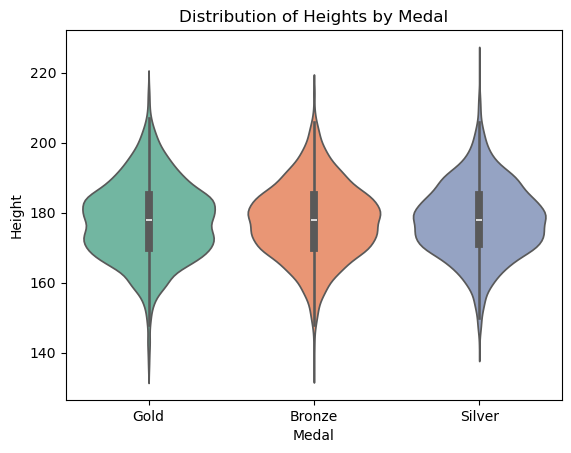

In [17]:
# Distribution of heights by medal
sns.violinplot(data = df, x="Medal",y="Height", palette="Set2")
plt.title("Distribution of Heights by Medal")
plt.xlabel("Medal")
plt.ylabel("Height")
plt.show()

In [18]:
# Find which country have highest medal across all the sport total
most_medal_county = df["NOC"].value_counts().idxmax()
print("most Mdeal-Winning Country: ", most_medal_county)

most Mdeal-Winning Country:  USA


In [ ]:
# Find the tallest and heaviset athlete from which sport ,name...
tallest_althelet =df[df["Height"] == df["Height"].max()]
print("Tallest Althelet:")
print(tallest_althelet[['ID','Name', 'Height', 'Sport']])

# Heaviest
heaviset_althelet = df[df['Weight'] == df["Weight"].max()]
print("Heaviset Althelet:")
print(heaviset_althelet[['ID','Name', 'Weight', 'Sport']])

Heaviset Althelet:
          ID               Name  Height Sport
23155  12177  Ricardo Blas, Jr.   183.0  Judo
23156  12177  Ricardo Blas, Jr.   183.0  Judo


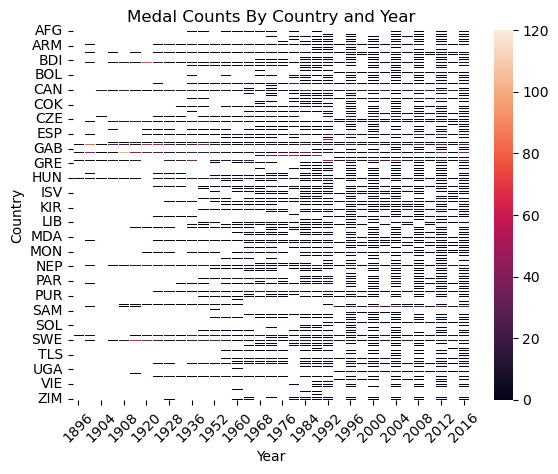

In [26]:
# Medal Counts By Country and Year (Using a heatmap)...
medals_by_country_year = df.pivot_table(index="NOC", columns="Year", values="Medal", aggfunc="count")
sns.heatmap(medals_by_country_year, linewidths=0.5)
plt.title("Medal Counts By Country and Year")
plt.xlabel("Year")
plt.ylabel("Country")
plt.xticks(rotation=45)
plt.show()